<a href="https://colab.research.google.com/github/saim9211/DeepLearning/blob/main/04_pytorch_custom_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# importing the pytorch libraries  and devicd agnostic code
import torch
from torch import nn

torch.__version__

'2.11.0+cpu'

In [3]:
# set up device code
device="cude" if torch.cuda.is_available() else "cpu"
device

'cpu'

### get the dataset

our dataset is subset of the food101 dataset
food101 start 101 diff classs of food and 1000 images per class (750 training and 250 test)

our data set with class 3 and only 10 per of the images (75 training ,25 testing)
why do this
when start ml project its impr to start with small dataset and tehn increase the scale when necessary
the whole point is to fast

In [4]:
import requests
import zipfile
from pathlib import Path

# set up  to data

data_path=Path("data/")
image_path=data_path/"pizza_steak_sushi"

#if image folder does not exist ,download it and prepare it
if image_path.is_dir():
  print(f"{image_path} directory already exist")
else:
  print(f"{image_path} directory not exist creating it ")
  image_path.mkdir(parents=True,exist_ok=True)
# download the data
with open(data_path/"pizza_steak_sushi.zip","wb") as f:
  request=requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("downlaoding the data in to raw folder")
  f.write(request.content)

# unzip the data
with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zip_ref:
  print("unzipping the data")
  zip_ref.extractall(image_path)

data/pizza_steak_sushi directory not exist creating it 
downlaoding the data in to raw folder
unzipping the data


Becoming one with the data(data preparation and data exploration)

In [5]:
import os
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory

  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [6]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.


In [7]:
# set up train and testing paths
train_dir=image_path/"train"
test_dir=image_path/"test"

visualizizing and image

let write some code :

* get all of the images paths
* pick a random image path using the python random.choice()
* get the image class name pathlib .path.parent.stem
* since we working with the images let open with the python pillow
* well then show the image and print  the meta data

In [8]:
!pip install PTL

data/pizza_steak_sushi/train/sushi/3579071.jpg
random image path:data/pizza_steak_sushi/train/sushi/3579071.jpg
image class:sushi
image height:512
image width:512


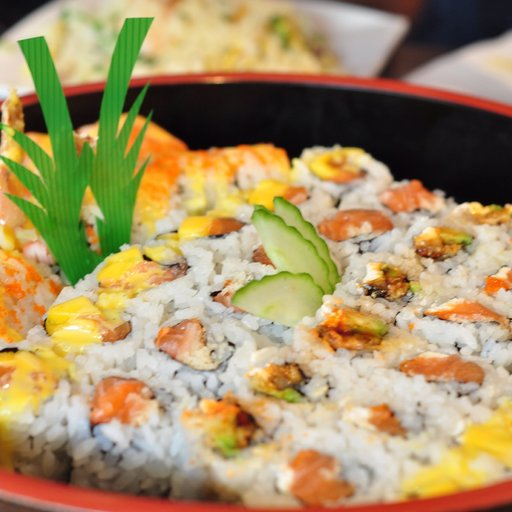

In [9]:
import random
from PIL import Image

# set  the random
random.seed(42)

# get all images paths
image_path_list=list(image_path.glob("*/*/*.jpg"))
#print(image_path)
# get the random image from the image path
random_image=random.choice(image_path_list)
print(random_image)
# get the image class from the path name (the image class is the  name of the directory where the image  stored )
image_class=random_image.parent.stem
#image_class

# open image
img=Image.open(random_image)
img
# print meta data
print(f"random image path:{random_image}")
print(f"image class:{image_class}")
print(f"image height:{img.height}")
print(f"image width:{img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

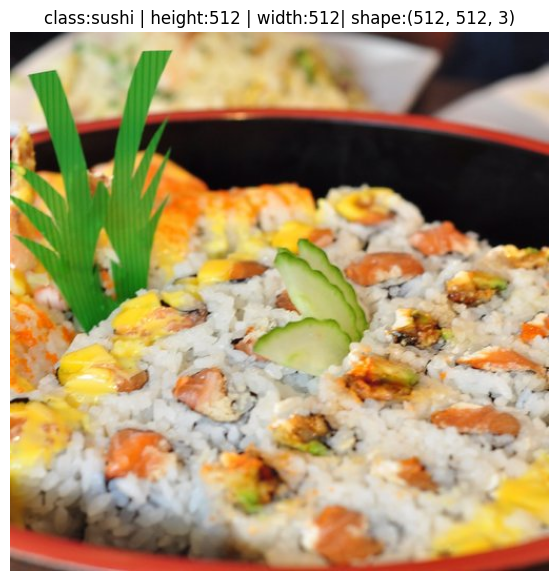

In [10]:
# dot he above with the matplot lib library
import numpy as np
import matplotlib.pyplot as plt

# turn the image in to array
img_arr=np.asarray(img)

#plot the image
plt.figure(figsize=(10,7))
plt.imshow(img_arr)
plt.title(f"class:{image_class} | height:{img.height} | width:{img.width}| shape:{img_arr.shape}")
plt.axis(False)

array([[[ 16,  14,  17],
        [ 16,  14,  17],
        [ 15,  13,  16],
        ...,
        [ 22,  22,  32],
        [ 22,  22,  32],
        [ 22,  22,  32]],

       [[ 16,  14,  17],
        [ 16,  14,  17],
        [ 16,  14,  17],
        ...,
        [ 22,  22,  32],
        [ 22,  22,  32],
        [ 22,  22,  32]],

       [[ 16,  14,  17],
        [ 16,  14,  17],
        [ 16,  14,  17],
        ...,
        [ 22,  22,  32],
        [ 22,  22,  32],
        [ 22,  22,  32]],

       ...,

       [[100,  70,  59],
        [100,  70,  59],
        [ 99,  70,  56],
        ...,
        [ 37,  22,  19],
        [ 37,  22,  19],
        [ 38,  23,  20]],

       [[ 99,  71,  59],
        [ 99,  71,  59],
        [ 98,  70,  58],
        ...,
        [ 40,  22,  20],
        [ 40,  22,  20],
        [ 40,  22,  20]],

       [[ 96,  70,  57],
        [ 96,  70,  57],
        [ 98,  70,  58],
        ...,
        [ 40,  22,  20],
        [ 41,  21,  20],
        [ 41,  21,  20]]], dtype=uint8)
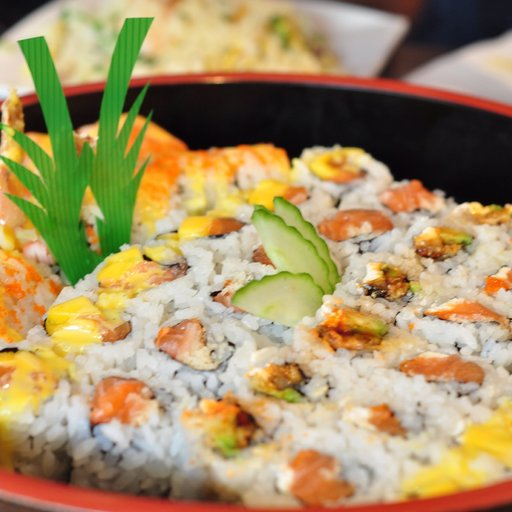

In [11]:
img_arr

Transforming data

before we use our image data with pytorch:
* turn your target data in to tensor ( inour case numerical representation of pur images)
* turn it in to  torch.utlis.data.Dataset and subsequently a
torch.utlis.data.DataLoader well call these dataset and the DataLoader for short

In [12]:
import torch
from torch.utils.data import dataloader
from torchvision import datasets,transforms

Tranforming data with torchvision.transforms

In [13]:
# write a transform for image

data_transform=transforms.Compose(
    [
        # resize image to 64*63
        transforms.Resize((64,64)),
        # flip the images randomly on the horizontal
        transforms.RandomHorizontalFlip(p=0.5),
        # turn the image in to a torch tensor
        transforms.ToTensor()
    ]
)

In [14]:
data_transform(img).shape

torch.Size([3, 64, 64])

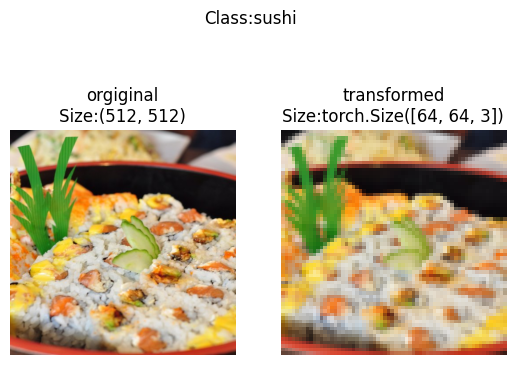

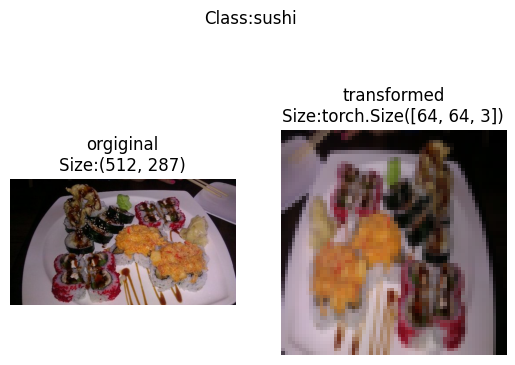

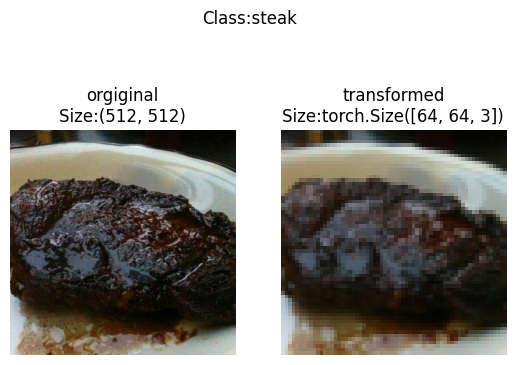

In [15]:
def plot_transformed_image(image_path,transform,n=3,seed=42):
  """ select the random images from the path of images and load /transform
  them then plots the original vs transformed version.
  """
  if seed:
    random.seed(seed)
    random_image=random.sample(image_path,k=n)
  for image_path in random_image:
    transformed_image=transform(Image.open(image_path))
    with Image.open(image_path) as f:
      fig,ax=plt.subplots(1,2)
      ax[0].imshow(f)
      ax[0].set_title(f"orgiginal\nSize:{f.size}")
      ax[0].axis(False)

      #Transform and plot the target image
      transformed_image=transform(f).permute(1,2,0) # we just  chaningthe order chw ->hwc
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"transformed\nSize:{transformed_image.shape}")
      ax[1].axis(False)

      fig.suptitle(f"Class:{image_path.parent.stem}",fontsize=12)
plot_transformed_image(image_path=image_path_list,
                       transform=data_transform,
                       n=3,
                       seed=42)


In [16]:
# loading the data set and image data


Loading the data using ImageFolder
* we can load image  classification data using torchvision,datasets.ImageFolder

In [17]:
# using the image folder
from torchvision import datasets
train_data=datasets.ImageFolder(root=train_dir,
                               transform=data_transform,
                               target_transform=None)
test_data=datasets.ImageFolder(root=test_dir,
                               transform=data_transform,
                               target_transform=None)
train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [22]:
# get  the class names
class_names=train_data.classes
class_names
# also able to get the class names as directory
class_name_dir=train_data.class_to_idx
class_name_dir
# get  the len
len(train_data),len(test_data)
# get the label
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [33]:
# index on the train_dataset to get a single image and label
img,label=train_data[0][0],train_data[0][1]
print(f"image tensor:\n{img}")
print(f"shape of the images:{img.shape}")
print(f"image datatype:{img.dtype}")
print(f"image label:{label}")
print(f"label datatype:{type(label)}")


image tensor:
tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.01

original shape:torch.Size([3, 64, 64])
permute shape:torch.Size([64, 64, 3])


Text(0.5, 1.0, 'pizza')

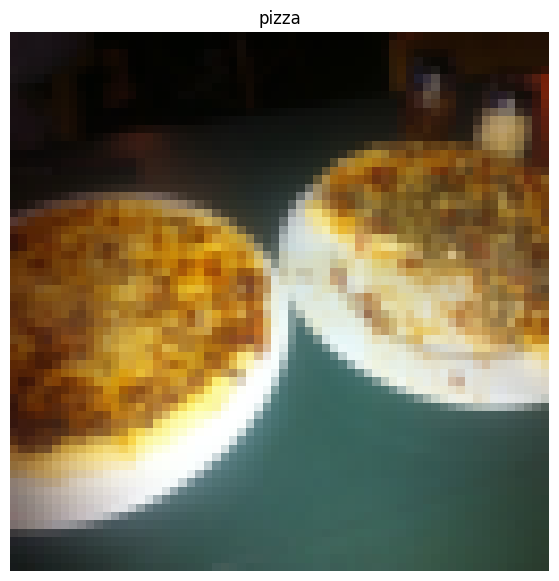

In [35]:
# rearange the order dimesnion
img_permute=img.permute(1,2,0)
# print out the different shapes
print(f"original shape:{img.shape}") # -> chw
print(f"permute shape:{img_permute.shape}") # hwc

#plot the image
plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis(False)
plt.title(class_names[label])

Turn the data in to dataloader

In [40]:
from torch.utils.data import DataLoader
train_dataloader=DataLoader(dataset=train_data,
                          batch_size=2,
                          num_workers=1,
                          shuffle=True)
test_dataloader=DataLoader(dataset=test_data,
                          batch_size=2,
                          num_workers=1,
                           shuffle=False)
train_dataloader,test_dataloader


(<torch.utils.data.dataloader.DataLoader at 0x79a0356e3200>,
 <torch.utils.data.dataloader.DataLoader at 0x79a0425c2d80>)

In [41]:
len(train_dataloader),len(train_data)

(113, 225)

In [42]:
print(f"train dataloader:{len(train_dataloader)} batches of {train_dataloader.batch_size} images")
print(f"test dataloader:{len(test_dataloader)} batches of {test_dataloader.batch_size} images")

train dataloader:113 batches of 2 images
test dataloader:38 batches of 2 images


iter(dataloader) -> iter can convert  the data loder in to iterable object
next()  -> can fetch the first  coming

In [43]:
img,label=next(iter(train_dataloader))

# batch size will now 1 and yu can change the batch size if like
print(f"image shape : {img.shape}")
print(f"lable shape: {label.shape}")

image shape : torch.Size([2, 3, 64, 64])
lable shape: torch.Size([2])
